In [1]:
# projekt_python_tindra_von_zweigbergk

# Elprisanalys projekt

Importering av olika bilbliotek

In [2]:
# ==============================================================================================================
# Importering av bibliotek
# ==============================================================================================================

import os
import csv
import requests
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

Importering av API
hejsan

In [3]:
# ==============================================================================================================
# Importering av API
# ==============================================================================================================


def get_electrical_prices(date_str, area="SE3"):
    # API-url (Format: ÅÅÅÅ/MM-DD_ZON.json)
    year, month, day = date_str[:4], date_str[5:7], date_str[8:10]
    url = f"https://www.elprisetjustnu.se/api/v1/prices/{year}/{month}-{day}_{area}.json"

    try:
        response = requests.get(url)
        response.raise_for_status()  
        return response.json() # Omvandlar json datan till python data
    except requests.exceptions.RequestException as e:
        print(f"Ett API-fel uppstod: {e}")
        return []


In [4]:
# ==============================================================================================================
# Klasser
# ==============================================================================================================
class ElectricityPrice: #Föräldrar klass
    def __init__(self, date, start_time, end_time, price, area):
        self.date = date
        self.start_time = start_time # Starttid när el priset börjar räknas
        self.end_time = end_time # Sluttiden när el pristet slutat räknas
        self.price = price      # I kronor
        self.area = area

    def is_expensive(self):
        return self.price >= 1.3

    def is_cheap(self):
        return self.price <= 0.4


class PriceAnalyzer:
    def __init__(self, price_list):
        self.price_list = price_list

    def find_expensive(self):
        return max(self.price_list, key=lambda x: x.price) 

    def find_cheap(self):
        return min(self.price_list, key = lambda x: x.price)

    def average_price(self):
        if not self.price_list:
            return 0
        total = sum(x.price for x in self.price_list)
        return total / len(self.price_list)

    def calculate_difference(self):
        return self.find_expensive().price - self.find_cheap().price

    def find_cheapest_period(self):
        cheap = self.find_cheap()
        return f"Billigast el: {cheap.start_time}-{cheap.end_time} ({cheap.price:.2f} SEK/kWh)"

    def find_most_expensive_period(self):
        expensive = self.find_expensive()
        return f"Dyraste el: {expensive.start_time}-{expensive.end_time} ({expensive.price:.2f} SEK/kWh)"


class AreaPrice(ElectricityPrice):
    AREA_NAMES = {
        "SE1": "Norra Sverige (Luleå)",
        "SE2": "Norra Mellansverige (Sundsvall)",
        "SE3": "Södra Mellansverige (Stockholm)",
        "SE4": "Södra Sverige (Malmö)",
    }

    def __init__(self, date, start_time, end_time, price, area):
        super().__init__(date, start_time, end_time, price, area)

        self.region_name = self.AREA_NAMES.get(area, "Okänt elområde")

    def area_description(self):
        return f"{self.area} - {self.region_name}"

    def get_status_text(self):
        if self.is_expensive():
            return "Elen är dyr"

        elif self.is_cheap():
            return "Elen är billig"

        return "Normalt elpris"



In [5]:
# ==============================================================================================================
# Funktioner
# ==============================================================================================================

def validate_area():
    while True:
        area_check = input("Ange det elområde du vill analysera (SE1, SE2, SE3 eller SE4): ")
        area_check = area_check.upper()

        if area_check not in ["SE1", "SE2", "SE3", "SE4"]:
            print("Ogiltigt område, vänligen försök igen!")
            continue

        return area_check


def create_price_objects(raw_data, date, area):
    objects = []

    for item in raw_data:
        obj = AreaPrice(
            date = date,
            start_time = item["time_start"][11:16],
            end_time = item["time_end"][11:16],
            price = item["SEK_per_kWh"],
            area = area
        )
        
        objects.append(obj)
    return objects



def analyze_price(date, area):
    raw_data = get_electrical_prices(date, area)

    if raw_data:
        objects = create_price_objects(raw_data, date, area)
        analyzer = PriceAnalyzer(objects)

        most_expensive = analyzer.find_expensive()
        cheapest = analyzer.find_cheap()
        average = analyzer.average_price()
        diff = analyzer.calculate_difference()

                    # Printa det analysen får fram
        
        print(f"Analys för {objects[0].area_description()} ({date})")
        print(f"\nMedelpriset för elen är {average:.2f} SEK/kWh")
        print(f"Högsta priset på elen är {most_expensive.price:.2f} SEK/kWh klockan {most_expensive.start_time} ({most_expensive.get_status_text()})")
        print(f"Lägsta priset för elen är {cheapest.price:.2f} SEK/kWh klockan {cheapest.start_time} ({cheapest.get_status_text()})")
        print(f"Priskillnaden är {diff:.2f} SEK/kWh\n")

        # Spara till CSV filen
        save_to_csv(objects)

        # Visa diagrammet (måste sen stänga ner fliken för diagrammet för att programmet ska fortsätta)
        print_diagram(objects, date, area)

    else:
        print("Kunde inte hitta några elpriser :(")



def print_diagram(price_list, date, area):
    times = []          
    prices = []

    for price in price_list: # Går igenom ElectricityPrice objektet
        times.append(price.start_time) # Går igenom ElectricityPrice objektet
        prices.append(price.price) # Går igenom ElectricityPrice objektet

    plt.figure(figsize=(12, 6))

    plt.plot(times, prices, marker="o")     # Skapar linjen i diagrammet

    plt.title(f"Diagram för elpriset för elområde {area} för datum {date} ")
    plt.xlabel("Tid")  
    plt.ylabel("Pris i SEK/kWh")

    plt.xticks(range(0, len(times), 4), times [::4], rotation=45)

    plt.tight_layout()
    plt.show()


def save_to_csv(price_list, filename="elpriser.csv"):
    try:
        file_exists = os.path.exists(filename)

        with open(filename, "a", newline="", encoding="utf-8") as file: # "a" för att den ska spara historik och utf-8 för åäö

            writer = csv.writer(file)

            if not file_exists:
                writer.writerow(
                    ["date", "area", "start_time", "end_time", "price" ]
                )

            for price in price_list:

            # Skriver varje ElectricityPrice-objekt
                writer.writerow([
                    price.date,
                    price.area,
                    price.start_time,
                    price.end_time,
                    price.price
                ])

        print(f"Data har sparats till {filename}")

    except OSError as e:
        print(f"Kunde inte spara CSV-filen: {e}")


-----------------------------------
Välkommen till AI Elprisanalysen!
-----------------------------------
1. Analysera dagens elpriser
2. Visa gårdagens elpriser 
3. Avsluta programmet

Hämtar elpriser för 2026-09-23 i elområdet SE1... 

Analys för SE1 - Norra Sverige (Luleå) (2026-09-23)

Medelpriset för elen är 0.86 SEK/kWh
Högsta priset på elen är 1.84 SEK/kWh klockan 18:00 (Elen är dyr)
Lägsta priset för elen är 0.09 SEK/kWh klockan 06:00 (Elen är billig)
Priskillnaden är 1.75 SEK/kWh

Data har sparats till elpriser.csv


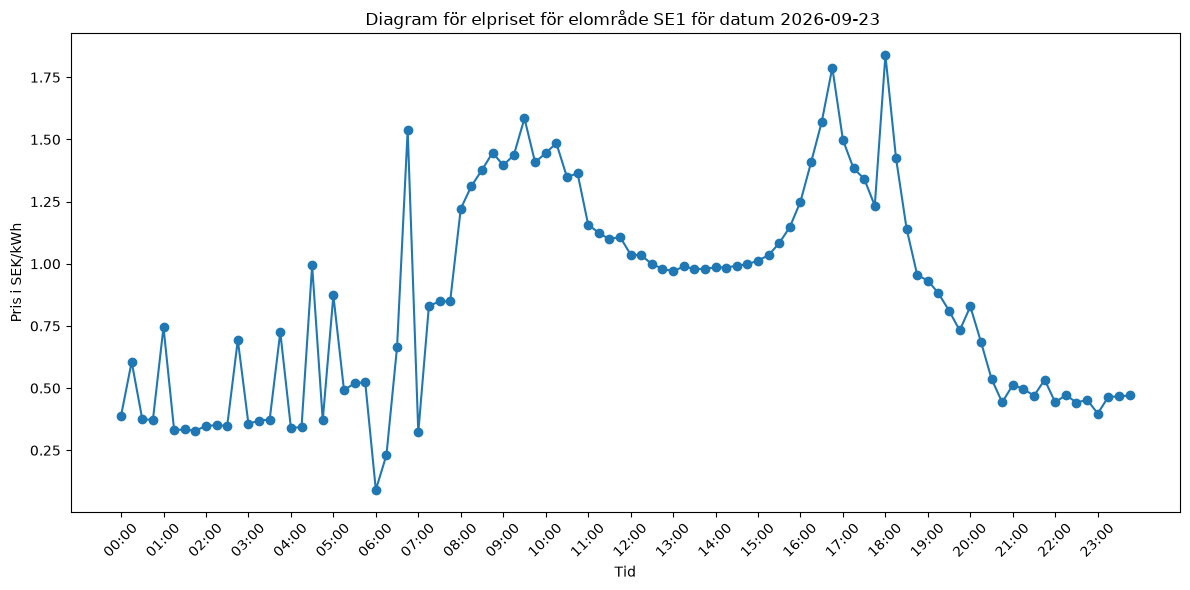

-----------------------------------
Välkommen till AI Elprisanalysen!
-----------------------------------
1. Analysera dagens elpriser
2. Visa gårdagens elpriser 
3. Avsluta programmet


In [6]:
# ==============================================================================================================
# Menyval
# ==============================================================================================================

while True:
    print("-"*35)
    print("Välkommen till AI Elprisanalysen!")
    print("-"*35)
    
    print("1. Analysera dagens elpriser")
    print("2. Visa gårdagens elpriser ")
    print("3. Avsluta programmet")

    val = input("Välj ett alternativ mellan 1-3: ")

    if val == "1":

        date = datetime.now().strftime("%Y-%m-%d")
        area = validate_area()

        print(f"\nHämtar elpriser för {date} i elområdet {area}... \n")

        analyze_price(date, area)


    elif val == '2':
        date_yesterday = (datetime.now() - timedelta(days=1)).strftime("%Y-%m-%d") # Gårdagens datum

        area = validate_area()
        analyze_price(date_yesterday, area)

    elif val == '3':
        break

    else:
        print("Ogiltigt val, vänligen försök igen!\n")
